In [1]:
##Step1: Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

In [2]:
##STEP 2: Load Dataset

df = pd.read_csv("amazon_reviews.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
##STEP 3: Select Required Columns

df = df[['product_name','category','rating','review_content']]
df.head()

,product_name,category,rating,review_content
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,4.2,Looks durable Charging is fine tooNo complains...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,4.0,I ordered this cable to connect my phone to An...
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,3.9,"Not quite durable and sturdy,https://m.media-a..."
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,4.2,"Good product,long wire,Charges good,Nice,I bou..."
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,4.2,"Bought this instead of original apple, does th..."


In [4]:
##STEP 4: Data Cleaning

# Convert rating to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Remove null values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['cleaned_review'] = df['review_content'].apply(clean_text)

df.head()

,product_name,category,rating,review_content,cleaned_review
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,4.2,Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,4.0,I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,3.9,"Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdyhttpsmmediaamazonc...
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,4.2,"Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,4.2,"Bought this instead of original apple, does th...",bought this instead of original apple does the...


In [5]:
##STEP 5: NLP-Based Sentiment Analysis

positive_words = ['good','excellent','best','amazing','perfect','nice','love','great','fast','awesome']
negative_words = ['bad','worst','poor','waste','delay','problem','issue','slow','broken','damage']

def text_sentiment(text):
    words = str(text).lower().split()
    
    pos = sum(word in positive_words for word in words)
    neg = sum(word in negative_words for word in words)
    
    score = pos - neg
    
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['cleaned_review'].apply(text_sentiment)

df['sentiment'].value_counts()

sentiment
Positive    1219
Neutral       88
Negative      49
Name: count, dtype: int64

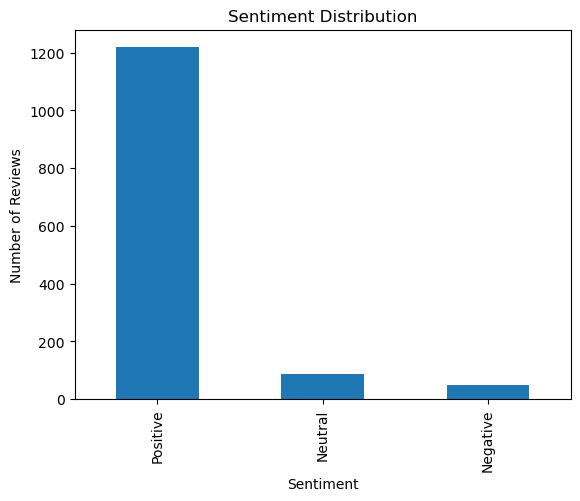

In [6]:
##STEP 6: Sentiment Visualization

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [7]:
##STEP 7: Detect Common Complaints

negative_reviews = df[df['sentiment']=='Negative']['cleaned_review']

words = " ".join(negative_reviews).split()
common_negative_words = Counter(words).most_common(15)

print("Common Complaint Words:", common_negative_words)

Common Complaint Words: [('the', 575), ('to', 382), ('and', 358), ('is', 302), ('i', 259), ('it', 247), ('a', 217), ('for', 208), ('of', 181), ('this', 155), ('in', 152), ('not', 143), ('product', 130), ('have', 114), ('with', 106)]


In [8]:
##STEP 8: Identify What Customers Like

positive_reviews = df[df['sentiment']=='Positive']['cleaned_review']

words = " ".join(positive_reviews).split()
common_positive_words = Counter(words).most_common(15)

print("Common Positive Words:", common_positive_words)

Common Positive Words: [('the', 10900), ('is', 8386), ('and', 7864), ('to', 6552), ('it', 5897), ('for', 5508), ('a', 5136), ('i', 4632), ('good', 4002), ('of', 3788), ('this', 3703), ('in', 3398), ('but', 2892), ('with', 2719), ('not', 2716)]


In [9]:
##STEP 9: Category-Level Analysis

category_analysis = df.groupby('category')['sentiment'].value_counts()
print(category_analysis)

category                                                                                                                sentiment
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                  Positive     1
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                 Positive     2
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                         Positive     1
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                      Positive     2
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                         Positive     2
                                                                                                                                    ..
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pen

In [10]:
##STEP 10: Identify High-Complaint Products

top_negative_products = df[df['sentiment']=='Negative']['product_name'].value_counts().head(10)

print("Top Products with Complaints:\n", top_negative_products)

Top Products with Complaints:
 product_name
Sounce Gold Plated 3.5 mm Headphone Splitter for Computer 2 Male to 1 Female 3.5mm Headphone Mic Audio Y Splitter Cable Smartphone Headset to PC Adapter – (Black,20cm)    2
Samsung 80 cm (32 Inches) Wondertainment Series HD Ready LED Smart TV UA32T4340BKXXL (Glossy Black)                                                                        1
Butterfly EKN 1.5-Litre Electric Kettle (Silver with Black)                                                                                                                1
USHA Heat Convector 812 T 2000-Watt with Instant Heating Feature (Black)                                                                                                   1
Prestige Iris 750 Watt Mixer Grinder with 3 Stainless Steel Jar + 1 Juicer Jar (White and Blue)                                                                            1
Themisto 350 Watts Egg Boiler-Blue                                                         

In [11]:
##STEP 11: KPI Metrics

total_reviews = len(df)
positive_percent = (df['sentiment']=='Positive').mean()*100
negative_percent = (df['sentiment']=='Negative').mean()*100

print("Total Reviews:", total_reviews)
print("Positive %:", positive_percent)
print("Negative %:", negative_percent)

Total Reviews: 1356
Positive %: 89.89675516224189
Negative %: 3.6135693215339235


In [12]:
##STEP 12: AUTOMATED INSIGHT GENERATION

def generate_insights(df):
    insights = []
    
    pos = (df['sentiment']=='Positive').mean()*100
    neg = (df['sentiment']=='Negative').mean()*100
    
    if pos > 60:
        insights.append("Overall customer satisfaction is high.")
    else:
        insights.append("Customer satisfaction needs improvement.")
    
    if neg > 20:
        insights.append("High negative sentiment detected. Immediate action required.")
    else:
        insights.append("Negative feedback is within acceptable limits.")
    
    top_negative_category = df[df['sentiment']=='Negative']['category'].value_counts().idxmax()
    insights.append(f"Most complaints are from category: {top_negative_category}")
    
    return insights

for insight in generate_insights(df):
    print(insight)

Overall customer satisfaction is high.
Negative feedback is within acceptable limits.
Most complaints are from category: Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions


In [13]:
##STEP 13: PRODUCT IMPROVEMENT OPPORTUNITIES 

print("Product Improvement Opportunities:")

for word, count in common_negative_words[:5]:
    print(f"Improve issues related to: {word}")

Product Improvement Opportunities:
Improve issues related to: the
Improve issues related to: to
Improve issues related to: and
Improve issues related to: is
Improve issues related to: i


In [14]:
##STEP 14: Save Final Output

df.to_csv("processed_reviews.csv", index=False)

In [15]:
positive_words = [
    'good','excellent','best','amazing','perfect','nice','love','great','fast','awesome'
]

negative_words = [
    'bad','worst','poor','waste','delay','problem','issue','slow','broken','damage',
    'defective','cheap','difficult','hard','return','refund','fail','error','notworking'
]

def text_sentiment(text):
    words = str(text).lower().split()
    
    pos = sum(word in positive_words for word in words)
    neg = sum(word in negative_words for word in words)
    
    score = pos - neg
    
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [28]:
def generate_insights(df):
    insights = []
    
    pos = (df['sentiment']=='Positive').mean()*100
    neg = (df['sentiment']=='Negative').mean()*100
    
    if pos > 80:
        insights.append(f"High customer satisfaction observed ({pos:.1f}% positive reviews).")
    
    if neg > 10:
        insights.append("Notable level of dissatisfaction detected, improvements required.")
    else:
        insights.append("Negative feedback is relatively low but should still be monitored.")
    
    # Category insight
    top_category = df[df['sentiment']=='Negative']['main_category'].value_counts().idxmax()
    insights.append(f"Major complaints are concentrated in the {top_category} category.")
    
    # Issue-based insight
    insights.append("Common issues include product quality, battery performance, and charging problems.")
    
    return insights

In [29]:
def ai_customer_insight_system(df):
    
    # Step 1: Sentiment Analysis
    df['sentiment'] = df['cleaned_review'].apply(text_sentiment)
    
    # Step 2: Clean Category
    df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])
    
    # Step 3: KPI Calculation
    pos = (df['sentiment'] == 'Positive').mean() * 100
    neg = (df['sentiment'] == 'Negative').mean() * 100
    
    # Step 4: Generate Insights
    insights = generate_insights(df)
    
    # Step 5: Complaint Extraction (FINAL IMPROVED)
    
    stopwords = [
        'the','is','and','to','i','a','of','for','in','on','it','this','that',
        'with','as','was','are','be','have','has','had','you','they','we','he','she',
        'not','but','very','my','from','so','if','which','its','product','one','all',
        'can','will','just','about','more','also','only','after','before','than',
        'used','need','installed','received','using','get','got','make',
        'working','being','getting','buying','made','like'
    ]
    
    # Strong complaint keywords (domain-focused)
    problem_keywords = [
        'delay','broken','damage','poor','issue','problem','defective',
        'slow','bad','error','fail','return','refund','heating',
        'charging','battery','noise','quality'
    ]
    
    negative_reviews = df[df['sentiment'] == 'Negative']['cleaned_review']
    
    words = " ".join(negative_reviews).split()
    
    # Filter meaningful complaint words
    filtered_words = [
        word for word in words
        if word not in stopwords and len(word) > 4 and word in problem_keywords
    ]
    
    from collections import Counter
    
    if filtered_words:
        common_issues = Counter(filtered_words).most_common(10)
    else:
        common_issues = [("No major issues detected", 0)]
    
    # Step 6: Top Complaint Category
    if len(df[df['sentiment'] == 'Negative']) > 0:
        top_category = df[df['sentiment'] == 'Negative']['main_category'].value_counts().idxmax()
    else:
        top_category = "No significant complaints"
    
    # Step 7: FINAL OUTPUT
    print(" AI Customer Insight Report")
    
    print("\n Sentiment Summary:")
    print(f"Positive: {pos:.2f}%")
    print(f"Negative: {neg:.2f}%")
    
    print("\n Key Issues (from customer complaints):")
    for word, count in common_issues:
        print(f"{word} ({count} times)")
    
    print("\n Category with Most Complaints:")
    print(f" {top_category}")
    
    print("\n AI Generated Insights:")
    for i in insights:
        print(f"{i}")
    
    return df

In [30]:
ai_customer_insight_system(df)

 AI Customer Insight Report

 Sentiment Summary:
Positive: 85.55%
Negative: 6.56%

 Key Issues (from customer complaints):
quality (108 times)
problem (52 times)
battery (52 times)
issue (48 times)
charging (38 times)
return (20 times)
defective (17 times)
heating (16 times)
broken (11 times)
noise (9 times)

 Category with Most Complaints:
 Home&Kitchen

 AI Generated Insights:
High customer satisfaction observed (85.5% positive reviews).
Negative feedback is relatively low but should still be monitored.
Major complaints are concentrated in the Home&Kitchen category.
Common issues include product quality, battery performance, and charging problems.


,product_name,category,rating,review_content,cleaned_review,sentiment,main_category
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,4.2,Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...,Positive,Computers&Accessories
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,4.0,I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...,Positive,Computers&Accessories
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,3.9,"Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdyhttpsmmediaamazonc...,Positive,Computers&Accessories
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,4.2,"Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...,Positive,Computers&Accessories
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,4.2,"Bought this instead of original apple, does th...",bought this instead of original apple does the...,Positive,Computers&Accessories
...,...,...,...,...,...,...,...
1460,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,4.0,"I received product without spanner,Excellent p...",i received product without spannerexcellent pr...,Positive,Home&Kitchen
1461,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,4.1,"ok,got everything as mentioned but the measuri...",okgot everything as mentioned but the measurin...,Neutral,Home&Kitchen
1462,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...",3.6,"plastic but cool body ,u have to find sturdy s...",plastic but cool body u have to find sturdy su...,Positive,Home&Kitchen
1463,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...",4.0,I have installed this in my kitchen working fi...,i have installed this in my kitchen working fi...,Negative,Home&Kitchen
